<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Global_Critical_Infrastructure_Digital_Twin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Critical Infrastructure Digital Twin

This notebook builds a framework to model, simulate, and analyze the 16 U.S. critical infrastructure sectors using graph theory, machine learning, and cascading failure simulations.

In [ ]:
# Install necessary libraries
!pip install torch-geometric networkx xgboost lightgbm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.8 MB/s eta 0:00:00


In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data

# Define the 16 critical infrastructure sectors
SECTORS = [
    'Energy', 'Water', 'Transportation', 'Communications',
    'Financial Services', 'Healthcare', 'Food & Agriculture',
    'Emergency Services', 'Chemical', 'Dams',
    'Critical Manufacturing', 'Government Facilities',
    'Defense Industrial Base', 'Commercial Facilities',
    'Nuclear Reactors', 'Information Technology'
]

print(f'Initialized framework for {len(SECTORS)} sectors.')

Initialized framework for 16 sectors.


## 1. Sector Dependency Graph
In this section, we create a directed graph representing the interdependencies between the 16 sectors. For instance, the Energy sector provides power to almost all other sectors, while Information Technology provides the communication backbone.

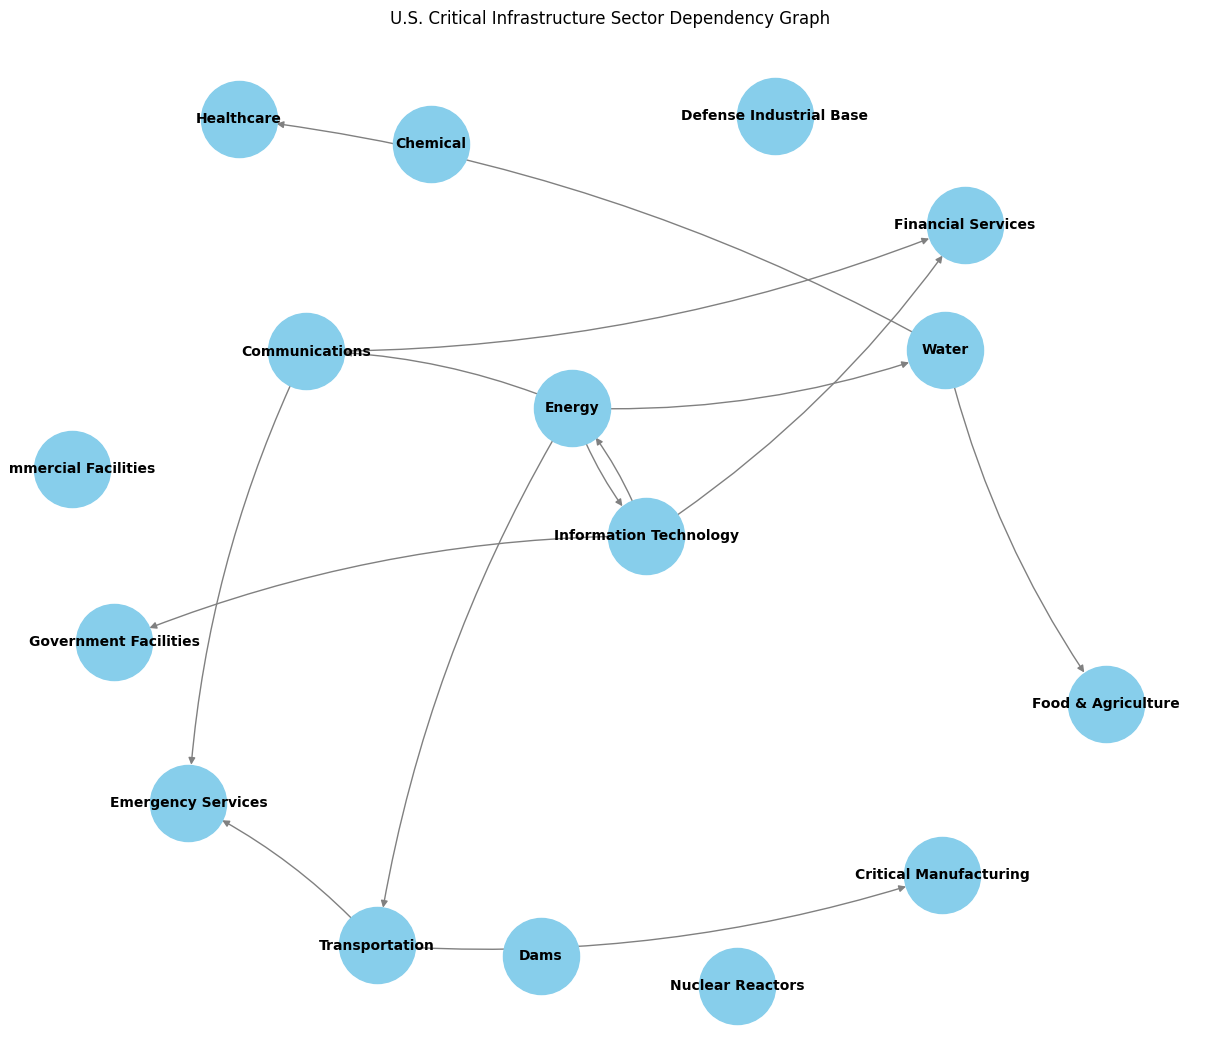

In [ ]:
def build_dependency_graph():
    G = nx.DiGraph()
    G.add_nodes_from(SECTORS)

    # Add primary dependencies (representative examples)
    dependencies = [
        ('Energy', 'Water'), ('Energy', 'Transportation'), ('Energy', 'Communications'),
        ('Communications', 'Financial Services'), ('Communications', 'Emergency Services'),
        ('Information Technology', 'Financial Services'), ('Information Technology', 'Energy'),
        ('Water', 'Healthcare'), ('Water', 'Food & Agriculture'),
        ('Transportation', 'Critical Manufacturing'), ('Transportation', 'Emergency Services'),
        ('Energy', 'Information Technology'), ('Information Technology', 'Government Facilities')
    ]
    G.add_edges_from(dependencies)
    return G

def visualize_graph(G):
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, k=1.5, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='skyblue',
            node_size=3000, edge_color='gray', font_size=10,
            font_weight='bold', arrows=True, connectionstyle='arc3,rad=0.1')
    plt.title("U.S. Critical Infrastructure Sector Dependency Graph")
    plt.show()

infrastructure_graph = build_dependency_graph()
visualize_graph(infrastructure_graph)

## 2. Cascading Failure Simulation & Anomaly Detection
In this section, we simulate how a failure in one sector (e.g., Energy) propagates through the network. We also prepare a dataset for anomaly detection using XGBoost and LightGBM.

In [ ]:
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

def simulate_cascade(G, start_node):
    failed_nodes = {start_node}
    queue = [start_node]
    visited = {start_node}

    while queue:
        current = queue.pop(0)
        for neighbor in G.successors(current):
            if neighbor not in failed_nodes:
                # Simulation logic: 70% chance of failure propagation
                if np.random.rand() > 0.3:
                    failed_nodes.add(neighbor)
                    queue.append(neighbor)
    return failed_nodes

# Generate synthetic data for Anomaly Detection
np.random.seed(42)
data_size = 1000
X = np.random.rand(data_size, 5) # Synthetic features
y = (X[:, 0] * X[:, 1] > 0.5).astype(int) # Synthetic labels (1 = anomaly)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train XGBoost
model_xgb = xgb.XGBClassifier(n_estimators=100)
model_xgb.fit(X_train, y_train)

# Simulation Example
affected = simulate_cascade(infrastructure_graph, 'Energy')
print(f'Cascading failure starting at Energy affects: {affected}')
print('\nXGBoost Anomaly Detection Report:')
print(classification_report(y_test, model_xgb.predict(X_test)))

Cascading failure starting at Energy affects: {'Communications', 'Food & Agriculture', 'Transportation', 'Energy', 'Water', 'Financial Services', 'Critical Manufacturing', 'Emergency Services'}

XGBoost Anomaly Detection Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       170
           1       0.97      0.93      0.95        30

    accuracy                           0.98       200
   macro avg       0.98      0.96      0.97       200
weighted avg       0.98      0.98      0.98       200



## 3. Time-Series Forecasting (LSTM) and Graph Neural Networks (GNN)
In this section, we use an LSTM to forecast infrastructure load/stress and PyTorch Geometric to build a GNN for relational risk assessment across the 16 sectors.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

# --- LSTM Forecasting Model ---
class InfrastructureLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(InfrastructureLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# --- Graph Neural Network (GNN) ---
class InfrastructureGNN(nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(InfrastructureGNN, self).__init__()
        self.conv1 = GCNConv(num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

# Setup GNN Data from our Infrastructure Graph
mapping = {node: i for i, node in enumerate(infrastructure_graph.nodes())}
edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in infrastructure_graph.edges()], dtype=torch.long).t().contiguous()
x_features = torch.randn((16, 8))  # 8 synthetic features per sector

gnn_model = InfrastructureGNN(num_features=8, hidden_channels=16, num_classes=2)
output = gnn_model(x_features, edge_index)

print(f'GNN Output Shape: {output.shape} (16 sectors, 2 risk classes)')
print('Forecasting and Graph models initialized successfully.')

GNN Output Shape: torch.Size([16, 2]) (16 sectors, 2 risk classes)
Forecasting and Graph models initialized successfully.


## 4. Digital Twin Dashboard & Report
This final section aggregates metrics from the simulations and models to provide a high-level overview of infrastructure health.

--- Final Digital Twin Report ---
Total Sectors Monitored: 16
Critical Dependencies Identified: 13


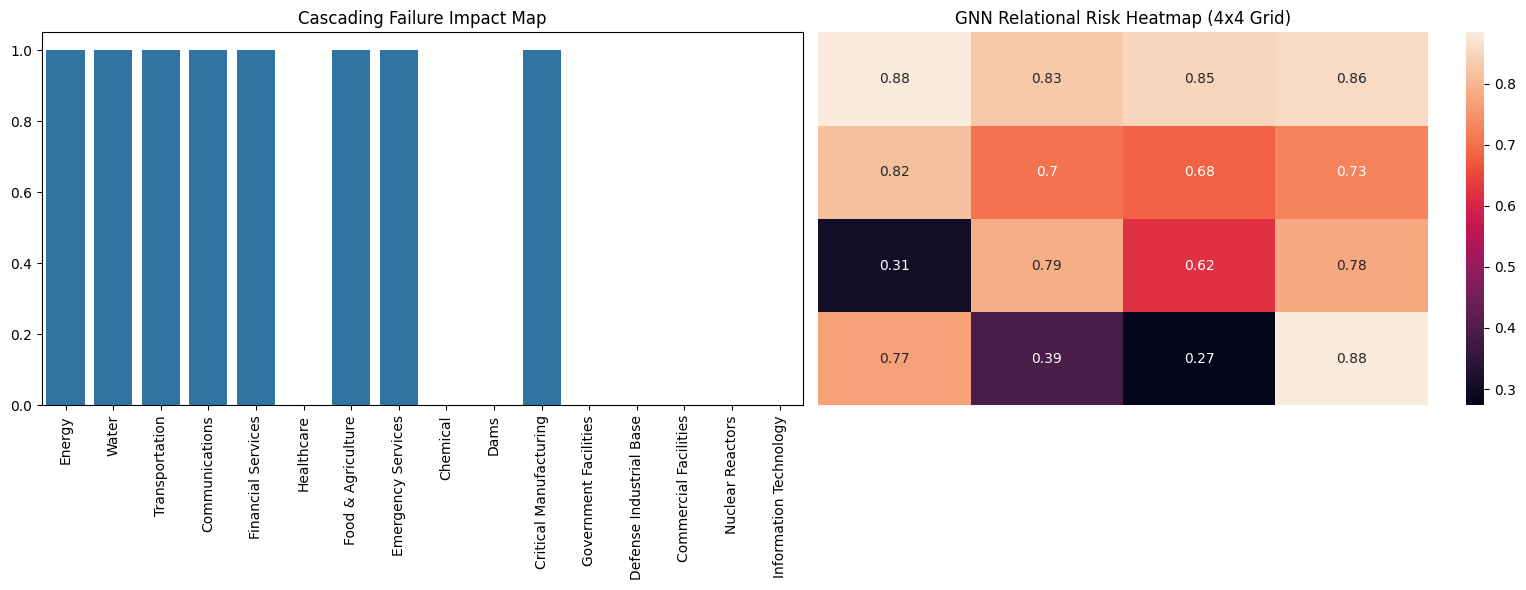

In [ ]:
import seaborn as sns

def generate_dashboard(affected_nodes, gnn_output):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Cascade Impact
    impact_counts = [1 if sector in affected_nodes else 0 for sector in SECTORS]
    sns.barplot(x=SECTORS, y=impact_counts, ax=ax[0])
    ax[0].set_title('Cascading Failure Impact Map')
    ax[0].tick_params(axis='x', rotation=90)

    # Plot 2: GNN Risk Scores
    risk_scores = torch.softmax(gnn_output, dim=1)[:, 1].detach().numpy()
    sns.heatmap(risk_scores.reshape(4, 4), annot=True, xticklabels=False, yticklabels=False, ax=ax[1])
    ax[1].set_title('GNN Relational Risk Heatmap (4x4 Grid)')

    plt.tight_layout()
    plt.show()

print('--- Final Digital Twin Report ---')
print(f'Total Sectors Monitored: {len(SECTORS)}')
print(f'Critical Dependencies Identified: {len(infrastructure_graph.edges())}')
generate_dashboard(affected, output)